# Roostoo universe EDA (~67 tokens)

Loads **`data/research_roostoo_1m.duckdb`** and analyzes **all** symbols (cross-sectional).

**Database refresh** lives in **`research/db/`** — see `research/db/README.md` and run `load_1m_roostoo_universe.py` or open `inspect_duckdb.ipynb` there.

Run cells top-to-bottom. Cwd can be repo root or `research/`.

In [1]:
import sys
import subprocess

for pkg in ("pandas", "numpy", "matplotlib", "seaborn", "duckdb"):
    try:
        __import__(pkg)
    except ModuleNotFoundError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

In [2]:
def repo_root() -> Path:
    p = Path.cwd().resolve()
    for _ in range(10):
        if (p / "research" / "eda_marimo.ipynb").exists() and (p / "data").is_dir():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise RuntimeError(
        "Could not find repo root (expected research/eda_marimo.ipynb + data/). "
        f"cwd={Path.cwd().resolve()}"
    )


ROOT = repo_root()
DB_FILE = ROOT / "data" / "research_roostoo_1m.duckdb"

if not DB_FILE.exists():
    raise FileNotFoundError(
        f"Missing {DB_FILE}\n"
        "Build from repo root — see research/db/README.md:\n"
        "  python research/db/load_1m_roostoo_universe.py --db data/research_roostoo_1m.duckdb\n"
    )

con = duckdb.connect(str(DB_FILE), read_only=True)
print("Repo:", ROOT)
print("DuckDB:", DB_FILE)

Repo: /Users/ankoo/Desktop/Projects/Margin Call Capital 2.0/margincallcapital
DuckDB: /Users/ankoo/Desktop/Projects/Margin Call Capital 2.0/margincallcapital/data/research_roostoo_1m.duckdb


In [3]:
# Universe check: expect ~67 distinct bases (Roostoo USD pairs)
EXPECTED_TOKENS = 67

intervals_avail = con.execute(
    "SELECT interval, COUNT(*)::BIGINT AS n FROM ohlcv GROUP BY 1 ORDER BY 1"
).df()
display(intervals_avail)

# Use 1h for universe plots (manageable rows); change if you only loaded 1m
ITV = "1h"
if ITV not in set(intervals_avail["interval"]):
    ITV = intervals_avail.sort_values("n", ascending=False).iloc[0]["interval"]
    print(f"Fallback ITV = {ITV!r} (1h not found)")

symbols = con.execute(
    "SELECT DISTINCT symbol FROM ohlcv WHERE interval = ? ORDER BY symbol",
    [ITV],
).df()["symbol"].tolist()

n_sym = len(symbols)
print(f"\nInterval: {ITV} | distinct symbols: {n_sym} (expected ~{EXPECTED_TOKENS})")
if n_sym < EXPECTED_TOKENS - 2:
    print(
        "⚠ Fewer symbols than full Roostoo universe — re-run the loader without --limit, "
        "or check roostoo_load_meta / failed downloads."
    )
symbols[:8], "...", symbols[-3:]

,interval,n
0,15m,455366
1,1h,114683
2,1m,6782025
3,5m,1360389



Interval: 1h | distinct symbols: 67 (expected ~67)


(['1000CHEEMS-USD',
  'AAVE-USD',
  'ADA-USD',
  'APT-USD',
  'ARB-USD',
  'ASTER-USD',
  'AVAX-USD',
  'AVNT-USD'],
 '...',
 ['XRP-USD', 'ZEC-USD', 'ZEN-USD'])

In [4]:
# Per-symbol coverage (same interval as universe EDA)
coverage = con.execute(
    """
    SELECT symbol,
           COUNT(*)::BIGINT AS n_rows,
           MIN(ts) AS min_ts,
           MAX(ts) AS max_ts
    FROM ohlcv
    WHERE interval = ?
    GROUP BY 1
    ORDER BY symbol
    """,
    [ITV],
).df()
coverage["min_ts"] = pd.to_datetime(coverage["min_ts"])
coverage["max_ts"] = pd.to_datetime(coverage["max_ts"])
display(coverage)
print(f"Total rows ({ITV}): {coverage['n_rows'].sum():,}")

,symbol,n_rows,min_ts,max_ts
0,1000CHEEMS-USD,1711,2025-12-19 17:00:00,2026-02-28 23:00:00
1,AAVE-USD,1711,2025-12-19 17:00:00,2026-02-28 23:00:00
2,ADA-USD,1711,2025-12-19 17:00:00,2026-02-28 23:00:00
3,APT-USD,1711,2025-12-19 17:00:00,2026-02-28 23:00:00
4,ARB-USD,1711,2025-12-19 17:00:00,2026-02-28 23:00:00
...,...,...,...,...
62,XLM-USD,1711,2025-12-19 17:00:00,2026-02-28 23:00:00
63,XPL-USD,1711,2025-12-19 17:00:00,2026-02-28 23:00:00
64,XRP-USD,1711,2025-12-19 17:00:00,2026-02-28 23:00:00
65,ZEC-USD,1711,2025-12-19 17:00:00,2026-02-28 23:00:00


Total rows (1h): 114,683


In [5]:
# Wide close matrix: all symbols, aligned timestamps
long_px = con.execute(
    "SELECT ts, symbol, close, volume FROM ohlcv WHERE interval = ? ORDER BY ts, symbol",
    [ITV],
).df()
long_px["ts"] = pd.to_datetime(long_px["ts"])

close_w = long_px.pivot(index="ts", columns="symbol", values="close").sort_index()
vol_w = long_px.pivot(index="ts", columns="symbol", values="volume").sort_index()

print(close_w.shape, "(timesteps × symbols)")
close_w.iloc[:3, :6]

(2042, 67) (timesteps × symbols)


symbol,1000CHEEMS-USD,AAVE-USD,ADA-USD,APT-USD,ARB-USD,ASTER-USD
ts,,,,,,
2025-12-19 17:00:00,0.001006,181.87,0.3694,1.597,0.1867,0.697
2025-12-19 18:00:00,0.001008,182.98,0.3731,1.612,0.1897,0.706
2025-12-19 19:00:00,0.001017,185.36,0.3781,1.632,0.1935,0.724


In [6]:
# Simple imputation: forward-fill then drop rows still missing any coin (full universe only)
px = close_w.ffill().dropna(how="any")
rets = px.pct_change().dropna(how="any")
print("Return sample:", rets.shape, "|", rets.index.min(), "→", rets.index.max())

bars_per_year = {"1h": 24 * 365, "1m": 24 * 60 * 365, "5m": 12 * 24 * 365, "15m": 4 * 24 * 365}.get(
    ITV, 24 * 365
)

summary = pd.DataFrame(
    {
        "mean_ret": rets.mean(),
        "vol": rets.std(),
        "sharpe": rets.mean() / rets.std() * np.sqrt(bars_per_year),
        "n": rets.notna().sum(),
    }
).sort_values("sharpe", ascending=False)
display(summary.head(15))
display(summary.tail(5))

Return sample: (2041, 67) | 2025-12-19 18:00:00 → 2026-03-19 17:00:00


,mean_ret,vol,sharpe,n
symbol,,,,
PAXG-USD,0.000108,0.003538,2.852376,2041
VIRTUAL-USD,0.000085,0.011949,0.665058,2041
ASTER-USD,0.000060,0.009237,0.607932,2041
PUMP-USD,0.000071,0.012539,0.533266,2041
POL-USD,0.000056,0.009882,0.532140,2041
TRX-USD,0.000008,0.002120,0.353951,2041
OMNI-USD,0.000084,0.027660,0.284742,2041
SOMI-USD,0.000016,0.015811,0.093759,2041
PEPE-USD,0.000007,0.009978,0.066370,2041


,mean_ret,vol,sharpe,n
symbol,,,,
SEI-USD,-0.000213,0.006896,-2.885006,2041
ARB-USD,-0.000271,0.008453,-3.005667,2041
EIGEN-USD,-0.000322,0.009743,-3.090199,2041
ENA-USD,-0.000294,0.008832,-3.117163,2041
1000CHEEMS-USD,-0.000376,0.008401,-4.194059,2041


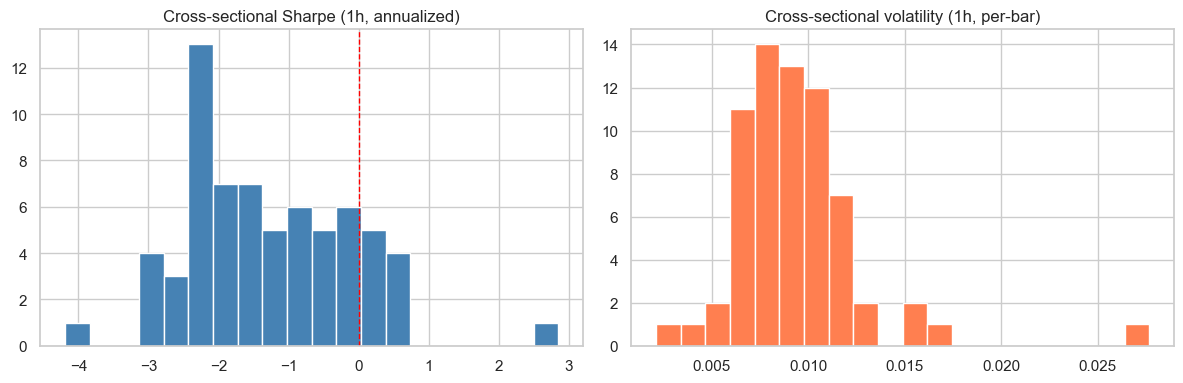

In [7]:
# Universe distribution: Sharpe & volatility
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(summary["sharpe"].dropna(), bins=20, color="steelblue", edgecolor="white")
axes[0].set_title(f"Cross-sectional Sharpe ({ITV}, annualized)")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1)

axes[1].hist(summary["vol"].dropna(), bins=20, color="coral", edgecolor="white")
axes[1].set_title(f"Cross-sectional volatility ({ITV}, per-bar)")
plt.tight_layout()
plt.show()

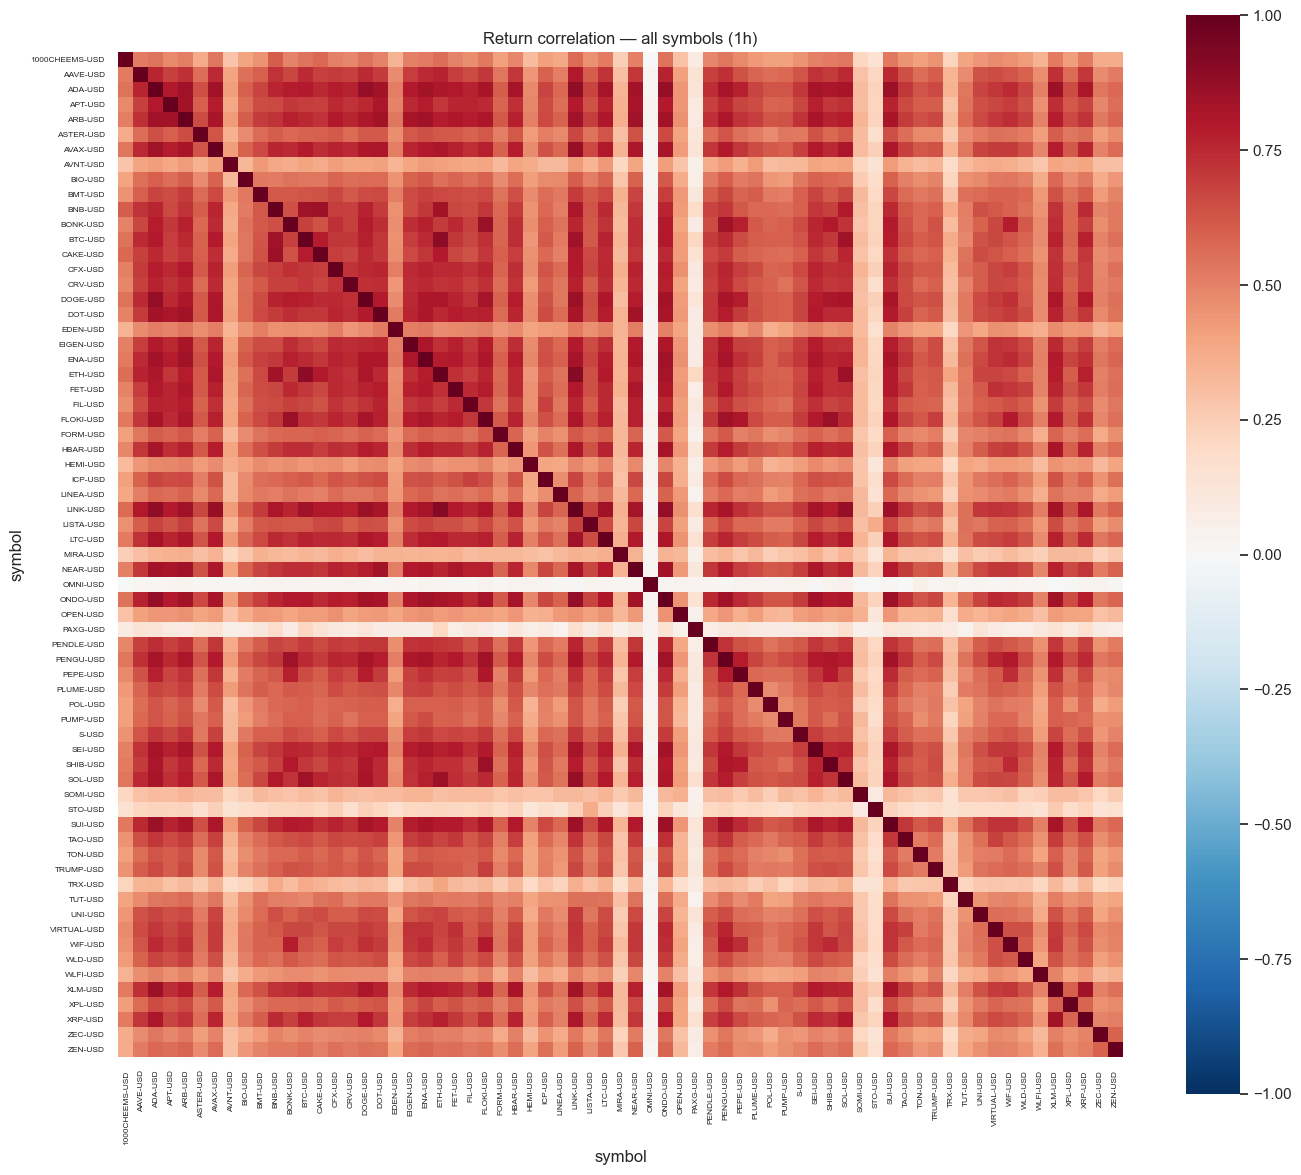

Mean pairwise corr: 0.539 | median: 0.573


In [8]:
# Full-universe correlation matrix (no annotations — too many names)
corr = rets.corr()
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    xticklabels=True,
    yticklabels=True,
    ax=ax,
)
ax.set_title(f"Return correlation — all symbols ({ITV})")
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()
plt.show()

mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
upper = corr.where(mask).stack()
print(f"Mean pairwise corr: {upper.mean():.3f} | median: {upper.median():.3f}")

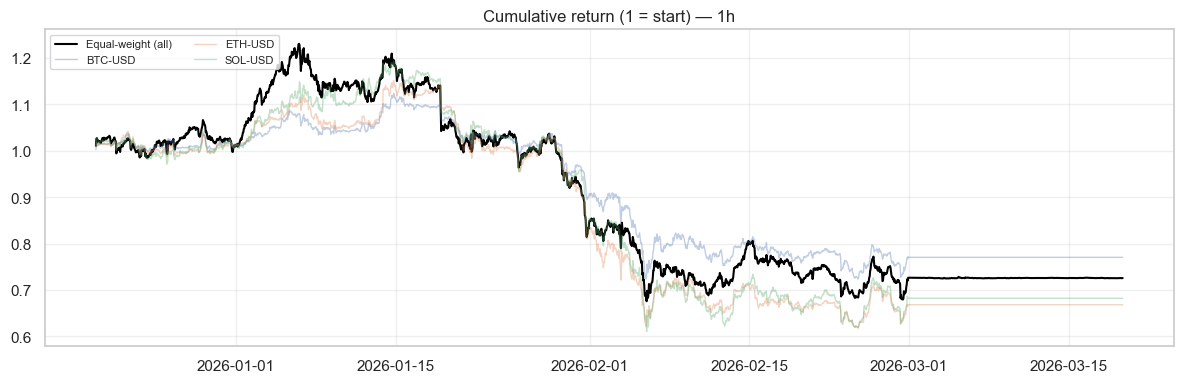

In [9]:
# Equal-weight universe index (normalized to 1)
ew = (1 + rets).cumprod()
ew["EW_PORTFOLIO"] = ew.mean(axis=1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ew.index, ew["EW_PORTFOLIO"], label="Equal-weight (all)", color="black", linewidth=1.5)
for c in ["BTC-USD", "ETH-USD", "SOL-USD"]:
    if c in ew.columns:
        ax.plot(ew.index, ew[c], alpha=0.35, linewidth=1, label=c)
ax.set_title(f"Cumulative return (1 = start) — {ITV}")
ax.legend(loc="upper left", fontsize=8, ncol=2)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

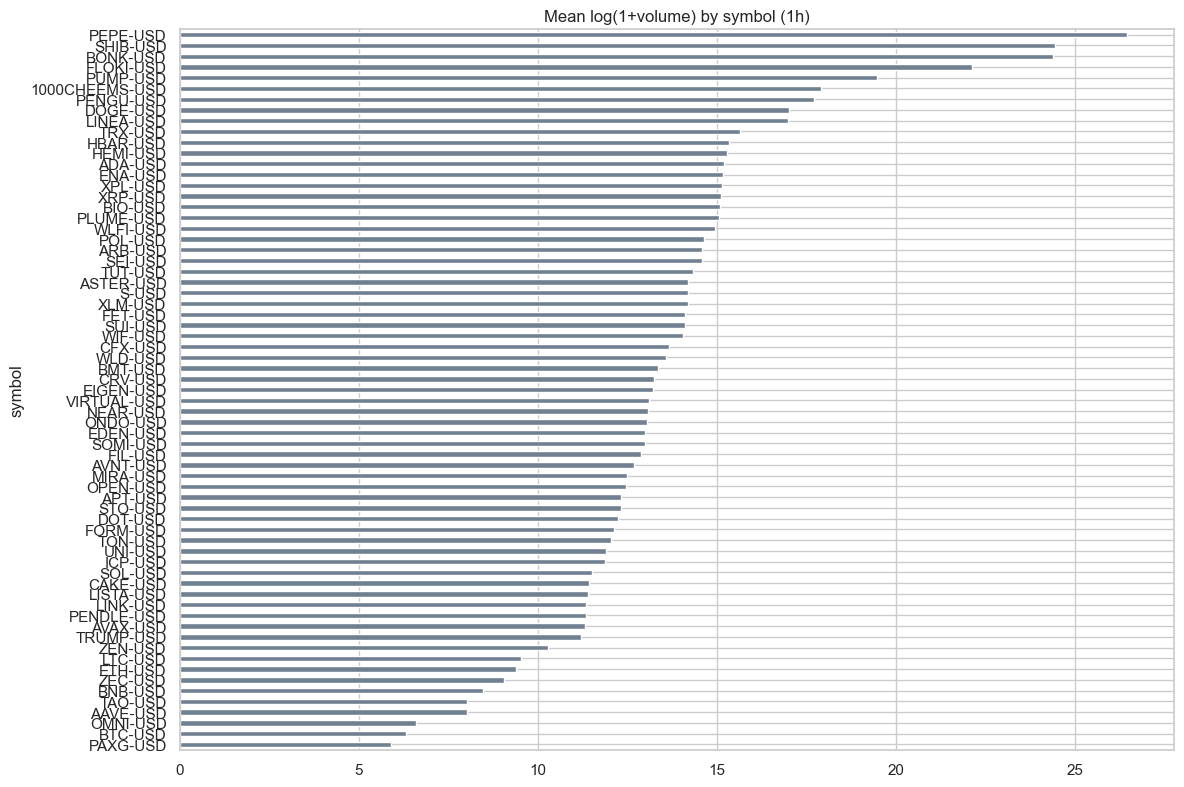

In [10]:
# Average log volume by symbol (universe cross-section)
v = vol_w.reindex(px.index).dropna(how="all")
lv = np.log1p(v)
mean_lv = lv.mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, max(4, len(mean_lv) * 0.12)))
mean_lv.iloc[::-1].plot(kind="barh", ax=ax, color="slategray")
ax.set_title(f"Mean log(1+volume) by symbol ({ITV})")
plt.tight_layout()
plt.show()

In [11]:
# Optional: duckdb.connect is cheap; restart kernel if you change DB on disk.
# con.close()

In [12]:
# Build technical feature set for 67-token universe from 1h returns (correlation/PCA-style + distributional stats)
import numpy as np
import pandas as pd

# Assumes con, ITV, close_w, px, rets exist from earlier cells in this notebook state
assert 'rets' in globals(), "Expected `rets` returns matrix to exist (run cells 5-6)."

rets_1h = rets.copy()

# --- (A) Return distribution features (interpretable) ---
tech_feat = pd.DataFrame(index=rets_1h.columns)
tech_feat["mean_ret"] = rets_1h.mean()
tech_feat["vol"] = rets_1h.std()
tech_feat["skew"] = rets_1h.skew()
tech_feat["kurt"] = rets_1h.kurtosis()
tech_feat["p01"] = rets_1h.quantile(0.01)
tech_feat["p99"] = rets_1h.quantile(0.99)
tech_feat["tail_1pct"] = tech_feat["p99"] - tech_feat["p01"]

# --- (B) Correlation-to-market and beta-to-market (equal-weight index) ---
mkt = rets_1h.mean(axis=1)  # equal-weight "market" return
tech_feat["corr_to_mkt"] = rets_1h.apply(lambda s: s.corr(mkt))
tech_feat["beta_to_mkt"] = rets_1h.apply(lambda s: s.cov(mkt) / mkt.var())

# --- (C) First principal-component exposure (no sklearn): eigenvector of corr matrix ---
C = rets_1h.corr().values
# Guard numerical issues
w, v = np.linalg.eigh(C)
pc1 = v[:, -1]
pc1 = pc1 / np.linalg.norm(pc1)
tech_feat["pc1_loading"] = pc1
tech_feat["pc1_abs_loading"] = np.abs(pc1)

# --- (D) Simple momentum proxy: last 7d vs last 30d cumulative return (1h bars) ---
bars_7d = 7 * 24
bars_30d = 30 * 24
cum = (1 + rets_1h).cumprod()
tech_feat["mom_7d"] = (cum.iloc[-1] / cum.iloc[-min(bars_7d, len(cum))] - 1).replace([np.inf, -np.inf], np.nan)
tech_feat["mom_30d"] = (cum.iloc[-1] / cum.iloc[-min(bars_30d, len(cum))] - 1).replace([np.inf, -np.inf], np.nan)

# Clean
tech_feat = tech_feat.replace([np.inf, -np.inf], np.nan).dropna()
print("Technical feature matrix:", tech_feat.shape)
display(tech_feat.head())

# Save for downstream clustering/classification
tech_feat.to_csv("outputs/eda/tech_features_67.csv")


Technical feature matrix: (67, 13)


,mean_ret,vol,skew,kurt,p01,p99,tail_1pct,corr_to_mkt,beta_to_mkt,pc1_loading,pc1_abs_loading,mom_7d,mom_30d
symbol,,,,,,,,,,,,,
1000CHEEMS-USD,-0.000376,0.008401,-0.395731,5.449388,-0.024022,0.022872,0.046894,0.598043,0.763409,0.096743,0.096743,0.0,-0.196296
AAVE-USD,-0.000206,0.007971,-0.582687,9.485511,-0.022619,0.020904,0.043523,0.811934,0.983367,0.131923,0.131923,0.0,0.008468
ADA-USD,-0.000105,0.007565,-0.106115,6.486964,-0.023616,0.020542,0.044159,0.912555,1.049031,0.148701,0.148701,0.0,0.073749
APT-USD,-0.000210,0.008711,-0.320881,6.016521,-0.024100,0.023910,0.048010,0.853600,1.129878,0.137805,0.137805,0.0,0.060639
ARB-USD,-0.000271,0.008453,-0.691345,8.478329,-0.023790,0.022623,0.046413,0.907533,1.165648,0.146573,0.146573,0.0,-0.093636


In [13]:
# Build a purely-technical token classification using correlation + simple distributional features
# Produces interpretable cluster labels for the 67-token universe.

from pathlib import Path

assert 'rets_1h' in globals(), "Expected rets_1h from earlier cells"
assert 'tech_feat' in globals(), "Expected tech_feat feature table from cell 12"

# (1) Correlation-distance matrix
corr_67 = rets_1h.corr()
dist = 1 - corr_67

# (2) Build a compact feature set for clustering (all interpretable)
feat_cols = [
    'vol', 'skew', 'kurt', 'tail_1pct', 'corr_to_mkt', 'beta_to_mkt',
    'pc1_abs_loading', 'mom_30d'
]
X = tech_feat[feat_cols].copy()

# Standardize (z-score) without sklearn
Xz = (X - X.mean()) / X.std(ddof=0)
Xz = Xz.replace([np.inf, -np.inf], np.nan).dropna()

# Keep correlation matrix aligned with tokens that survived feature cleaning
common = Xz.index.intersection(corr_67.index)
Xz = Xz.loc[common]
dist = dist.loc[common, common]

print("Clustering universe size:", len(common))

# (3) K-means (simple, interpretable centroid summaries) without sklearn
# We'll use a tiny implementation for k in [3..8] and pick based on inertia elbow.

def kmeans_numpy(X: np.ndarray, k: int, n_init: int = 25, n_iter: int = 200, seed: int = 0):
    rng = np.random.default_rng(seed)
    best = None
    best_inertia = np.inf

    for i in range(n_init):
        # k-means++-ish init: sample points uniformly for simplicity
        idx = rng.choice(X.shape[0], size=k, replace=False)
        centers = X[idx].copy()

        for _ in range(n_iter):
            # assign
            d2 = ((X[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
            labels = d2.argmin(axis=1)
            # update
            new_centers = np.vstack([
                X[labels == j].mean(axis=0) if np.any(labels == j) else centers[j]
                for j in range(k)
            ])
            if np.allclose(new_centers, centers, atol=1e-6, rtol=0):
                centers = new_centers
                break
            centers = new_centers

        inertia = ((X - centers[labels]) ** 2).sum()
        if inertia < best_inertia:
            best_inertia = inertia
            best = (labels.copy(), centers.copy(), inertia)

    return best  # labels, centers, inertia

X_arr = Xz.values
ks = list(range(3, 9))
results = []
for k in ks:
    labels, centers, inertia = kmeans_numpy(X_arr, k=k, seed=42)
    results.append((k, inertia))

inertia_df = pd.DataFrame(results, columns=['k', 'inertia'])
display(inertia_df)

# Choose a default k=5 (good balance for 67); user can adjust
k_default = 5
labels, centers, inertia = kmeans_numpy(X_arr, k=k_default, seed=42)

tech_labels = pd.DataFrame({
    'symbol': common,
    'tech_cluster': labels,
}).set_index('symbol')

# Summarize clusters in original (non-z) units for interpretability
cluster_summary = X.loc[common].join(tech_labels).groupby('tech_cluster').agg(['mean', 'median', 'count'])

print(f"\nTechnical clusters (k={k_default}) summary:")
display(cluster_summary)

# Save outputs
out_dir = Path('outputs/eda')
out_dir.mkdir(parents=True, exist_ok=True)
tech_labels.to_csv(out_dir / f'tech_clusters_k{k_default}.csv')
inertia_df.to_csv(out_dir / 'kmeans_inertia_scan.csv', index=False)

# Quick view: list tokens per cluster
for cl in sorted(tech_labels['tech_cluster'].unique()):
    members = tech_labels.index[tech_labels['tech_cluster'] == cl].tolist()
    print(f"Cluster {cl} (n={len(members)}):", ", ".join(members))


Clustering universe size: 67


,k,inertia
0,3,264.927104
1,4,201.145556
2,5,158.690004
3,6,109.024586
4,7,87.737732
5,8,79.167842



Technical clusters (k=5) summary:


vol                       skew                   \
                  mean    median count       mean     median count   
tech_cluster                                                         
0             0.008263  0.008224    37   0.070338  -0.093225    37   
1             0.010866  0.010653    22   0.483879   0.170776    22   
2             0.027660  0.027660     1   5.000368   5.000368     1   
3             0.016464  0.016464     2  14.078685  14.078685     2   
4             0.004401  0.004843     5  -0.872422  -0.750824     5   

                    kurt                   tail_1pct  ... corr_to_mkt  \
                    mean      median count      mean  ...       count   
tech_cluster                                          ...               
0               9.907707    7.783145    37  0.046931  ...          37   
1              16.180080    9.249272    22  0.060698  ...          22   
2              83.259116   83.259116     1  0.152315  ...           1   
3             429.616422  429.616422     2  0.066146  ...           2   
4              13.147064    9.790056     5  0.025555  ...           5   

             beta_to_mkt                 pc1_abs_loading                  \
                    mean    median count            mean    median count   
tech_cluster                                                               
0               1.057230  1.049031    37        0.136858  0.139159    37   
1               1.070671  1.025902    22        0.104081  0.106246    22   
2               0.398772  0.398772     1        0.005230  0.005230     1   
3               0.905985  0.905985     2        0.054118  0.054118     2   
4               0.423396  0.600895     5        0.093255  0.111906     5   

               mom_30d                  
                  mean    median count  
tech_cluster                            
0             0.052414  0.038763    37  
1            -0.048580 -0.072901    22  
2            -0.175325 -0.175325     1  
3             0.083956  0.083956     2  
4             0.012463  0.015490     5  

[5 rows x 24 columns]

Cluster 0 (n=37): AAVE-USD, ADA-USD, APT-USD, ARB-USD, AVAX-USD, BMT-USD, BONK-USD, CAKE-USD, CFX-USD, CRV-USD, DOGE-USD, DOT-USD, EIGEN-USD, ENA-USD, ETH-USD, FET-USD, FIL-USD, FLOKI-USD, HBAR-USD, LINK-USD, LTC-USD, NEAR-USD, ONDO-USD, PENDLE-USD, PENGU-USD, PEPE-USD, POL-USD, SEI-USD, SHIB-USD, SOL-USD, SUI-USD, TAO-USD, TRUMP-USD, UNI-USD, VIRTUAL-USD, XLM-USD, XRP-USD
Cluster 1 (n=22): 1000CHEEMS-USD, ASTER-USD, AVNT-USD, BIO-USD, EDEN-USD, FORM-USD, HEMI-USD, ICP-USD, LINEA-USD, LISTA-USD, OPEN-USD, PLUME-USD, PUMP-USD, S-USD, SOMI-USD, TUT-USD, WIF-USD, WLD-USD, WLFI-USD, XPL-USD, ZEC-USD, ZEN-USD
Cluster 2 (n=1): OMNI-USD
Cluster 3 (n=2): MIRA-USD, STO-USD
Cluster 4 (n=5): BNB-USD, BTC-USD, PAXG-USD, TON-USD, TRX-USD


In [14]:
# Fetch fundamentals (market cap, FDV proxy, categories) for the 67-token universe using CoinGecko (free)
import re
import time
import requests

# Symbols come from earlier cells (cell 3); for safety derive from tech_feat index
symbols_67 = list(tech_feat.index)

# Map our symbols like 'BTC-USD' -> coingecko 'bitcoin' via CoinGecko search
BASE = "https://api.coingecko.com/api/v3"

session = requests.Session()
session.headers.update({"accept": "application/json"})


def to_query(sym: str) -> str:
    # crude: use the base ticker before '-'
    return sym.split("-")[0].lower()


def cg_search(query: str):
    r = session.get(f"{BASE}/search", params={"query": query}, timeout=30)
    r.raise_for_status()
    return r.json().get("coins", [])


def pick_best_match(query: str, coins):
    # Prefer exact symbol match, then exact name match, else first result
    query_l = query.lower()
    exact_sym = [c for c in coins if c.get("symbol", "").lower() == query_l]
    if exact_sym:
        return exact_sym[0]
    exact_name = [c for c in coins if c.get("name", "").lower() == query_l]
    if exact_name:
        return exact_name[0]
    return coins[0] if coins else None


rows = []
misses = []

# CoinGecko rate limits; be gentle
for i, sym in enumerate(symbols_67, start=1):
    q = to_query(sym)
    try:
        coins = cg_search(q)
        best = pick_best_match(q, coins)
        if not best:
            misses.append(sym)
            continue

        coin_id = best["id"]
        # Pull market data and metadata (categories)
        r = session.get(
            f"{BASE}/coins/{coin_id}",
            params={
                "localization": "false",
                "tickers": "false",
                "market_data": "true",
                "community_data": "false",
                "developer_data": "false",
                "sparkline": "false",
            },
            timeout=30,
        )
        r.raise_for_status()
        j = r.json()
        md = j.get("market_data", {})

        mcap = md.get("market_cap", {}).get("usd")
        fdv = md.get("fully_diluted_valuation", {}).get("usd")
        circ = md.get("circulating_supply")
        total = md.get("total_supply")
        max_supply = md.get("max_supply")
        categories = j.get("categories", [])

        rows.append(
            {
                "symbol": sym,
                "cg_id": coin_id,
                "cg_symbol": best.get("symbol"),
                "cg_name": best.get("name"),
                "market_cap_usd": mcap,
                "fdv_usd": fdv,
                "circulating_supply": circ,
                "total_supply": total,
                "max_supply": max_supply,
                "n_categories": len(categories) if isinstance(categories, list) else None,
                "categories": ";".join(categories) if isinstance(categories, list) else None,
            }
        )

        # small sleep to be polite
        time.sleep(1.1)

    except Exception as e:
        misses.append(sym)
        continue

fund = pd.DataFrame(rows).set_index("symbol").sort_index()
print("Fundamentals fetched:", fund.shape, "| misses:", len(misses))
if misses:
    print("Missed (first 20):", misses[:20])

display(fund.head())

# Basic cleanup/derived features
fund_feat = fund.copy()
fund_feat["mcap_log"] = np.log1p(fund_feat["market_cap_usd"])
fund_feat["fdv_log"] = np.log1p(fund_feat["fdv_usd"])
fund_feat["fdv_to_mcap"] = fund_feat["fdv_usd"] / fund_feat["market_cap_usd"]

# Keep numeric columns for clustering
fund_num = fund_feat[["mcap_log", "fdv_log", "fdv_to_mcap", "n_categories"]].replace([np.inf, -np.inf], np.nan)

# Save raw pull
out_dir = Path("outputs/eda")
out_dir.mkdir(parents=True, exist_ok=True)
fund.to_csv(out_dir / "fundamentals_coingecko_raw.csv")
fund_num.to_csv(out_dir / "fundamentals_coingecko_numeric.csv")


Fundamentals fetched: (4, 10) | misses: 63
Missed (first 20): ['APT-USD', 'ARB-USD', 'ASTER-USD', 'AVAX-USD', 'AVNT-USD', 'BIO-USD', 'BMT-USD', 'BONK-USD', 'BTC-USD', 'CAKE-USD', 'CFX-USD', 'CRV-USD', 'DOGE-USD', 'DOT-USD', 'EDEN-USD', 'EIGEN-USD', 'ENA-USD', 'ETH-USD', 'FET-USD', 'FIL-USD']


,cg_id,cg_symbol,cg_name,market_cap_usd,fdv_usd,circulating_supply,total_supply,max_supply,n_categories,categories
symbol,,,,,,,,,,
1000CHEEMS-USD,1000chems,1000CHEEMS,1000CHEMS,0.000000e+00,99143232908,0.000000e+00,2.197761e+14,NaN,2,Meme;Multiplier Denominated Tokens
AAVE-USD,aave,AAVE,Aave,1.696962e+09,1788153617,1.518404e+07,1.600000e+07,1.600000e+07,26,Base Native;Huobi ECO Chain Ecosystem;Avalanch...
ADA-USD,cardano,ADA,Cardano,9.742979e+09,11900943836,3.684028e+10,4.500000e+10,4.500000e+10,9,Smart Contract Platform;Layer 1 (L1);Cardano E...
BNB-USD,binancecoin,BNB,BNB,8.680470e+10,86804700862,1.363577e+08,1.363577e+08,2.000000e+08,13,Smart Contract Platform;Exchange-based Tokens;...


In [16]:
# Improve CoinGecko fundamentals coverage by building a robust symbol->id map
import time
import requests
from pathlib import Path

assert 'tech_feat' in globals(), "Run technical features cell first (tech_feat)."
symbols_67 = list(tech_feat.index)
base_tickers = sorted({s.split('-')[0].upper() for s in symbols_67})

BASE = "https://api.coingecko.com/api/v3"
session = requests.Session()
session.headers.update({"accept": "application/json"})

# 1) Download full coin list (id, symbol, name) once
resp_list = session.get(f"{BASE}/coins/list", timeout=60)
# CoinGecko may rate-limit (429) and return a dict like {'status': {...}}; guard against that.
if resp_list.status_code == 429:
    print("CoinGecko rate limited (429) on /coins/list. Sleeping 10s then retrying once...")
    time.sleep(10)
    resp_list = session.get(f"{BASE}/coins/list", timeout=60)

coin_list = resp_list.json()
coins_df = pd.DataFrame(coin_list if isinstance(coin_list, list) else [])
if coins_df.empty or "symbol" not in coins_df.columns:
    raise RuntimeError(
        "CoinGecko /coins/list did not return a usable list (likely rate-limited). "
        "Try rerunning later, or use the earlier search-based `fund` (cell 14) as a partial fallback."
    )
coins_df["symbol"] = coins_df["symbol"].astype(str).str.upper()

# 2) Candidate ids by symbol (many-to-one); keep all candidates for later disambiguation
sym_to_ids = coins_df.groupby("symbol")["id"].apply(list).to_dict()

# 3) Heuristic: prefer ids where the name exactly matches common token name for majors; otherwise first id
# For now, just pick the first id per symbol and record ambiguity.
rows = []
ambiguous = []
missing = []
for tkr in base_tickers:
    ids = sym_to_ids.get(tkr)
    if not ids:
        missing.append(tkr)
        continue
    if len(ids) > 1:
        ambiguous.append((tkr, ids[:10]))
    rows.append({"ticker": tkr, "cg_id": ids[0], "n_candidates": len(ids)})

id_map = pd.DataFrame(rows).set_index("ticker").sort_index()
print(f"Tickers requested: {len(base_tickers)} | mapped: {len(id_map)} | missing: {len(missing)} | ambiguous: {len(ambiguous)}")
if missing:
    print("Missing tickers (no CG symbol match):", missing)
if ambiguous:
    print("Ambiguous tickers (showing first few ids):")
    for tkr, ids in ambiguous[:15]:
        print(f"  {tkr}: {ids}")

display(id_map.head())

# 4) Fetch fundamentals for mapped ids
fund_rows = []
errors = []
for i, (tkr, r) in enumerate(id_map.iterrows(), start=1):
    coin_id = r["cg_id"]
    try:
        resp = session.get(
            f"{BASE}/coins/{coin_id}",
            params={
                "localization": "false",
                "tickers": "false",
                "market_data": "true",
                "community_data": "false",
                "developer_data": "false",
                "sparkline": "false",
            },
            timeout=60,
        )
        if resp.status_code != 200:
            errors.append((tkr, coin_id, resp.status_code))
            continue
        j = resp.json()
        md = j.get("market_data", {})
        fund_rows.append(
            {
                "ticker": tkr,
                "cg_id": coin_id,
                "name": j.get("name"),
                "market_cap_usd": (md.get("market_cap") or {}).get("usd"),
                "fdv_usd": (md.get("fully_diluted_valuation") or {}).get("usd"),
                "circulating_supply": md.get("circulating_supply"),
                "total_supply": md.get("total_supply"),
                "max_supply": md.get("max_supply"),
                "categories": ";".join(j.get("categories", []) or []),
                "n_categories": len(j.get("categories", []) or []),
            }
        )
        time.sleep(0.8)  # be polite
    except Exception as e:
        errors.append((tkr, coin_id, repr(e)))

fund2 = pd.DataFrame(fund_rows).set_index("ticker").sort_index()
print(f"Fundamentals fetched: {fund2.shape} | errors: {len(errors)}")
if errors:
    print("First 10 errors:", errors[:10])

display(fund2.head())

# 5) Join back to our symbol universe and build numeric features
# Map ticker->symbol (we use XXX-USD in this notebook). If multiple symbols share ticker, they'd collide (not expected here).
ticker_to_symbol = {s.split('-')[0].upper(): s for s in symbols_67}
fund_symbol = fund2.copy()
fund_symbol["symbol"] = fund_symbol.index.map(ticker_to_symbol)
fund_symbol = fund_symbol.dropna(subset=["symbol"]).set_index("symbol")

fund_feat2 = pd.DataFrame(index=fund_symbol.index)
fund_feat2["mcap_log"] = np.log1p(fund_symbol["market_cap_usd"].astype(float))
fund_feat2["fdv_log"] = np.log1p(fund_symbol["fdv_usd"].astype(float))
fund_feat2["fdv_to_mcap"] = (fund_symbol["fdv_usd"].astype(float) / fund_symbol["market_cap_usd"].astype(float)).replace([np.inf, -np.inf], np.nan)
fund_feat2["n_categories"] = fund_symbol["n_categories"].astype(float)

print("Fund feature coverage vs 67 symbols:", fund_feat2.shape[0], "/", len(symbols_67))

# Save artifacts
out_dir = Path("outputs/eda")
out_dir.mkdir(parents=True, exist_ok=True)
id_map.to_csv(out_dir / "coingecko_symbol_id_map.csv")
fund2.to_csv(out_dir / "fundamentals_coingecko_by_ticker.csv")
fund_feat2.to_csv(out_dir / "fundamentals_features_coingecko.csv")


CoinGecko rate limited (429) on /coins/list. Sleeping 10s then retrying once...
Tickers requested: 67 | mapped: 67 | missing: 0 | ambiguous: 44
Ambiguous tickers (showing first few ids):
  ADA: ['binance-peg-cardano', 'cardano']
  ARB: ['arbitrage-loop', 'arbitrum']
  ASTER: ['aster-2', 'aster-3']
  AVAX: ['avalanche-2', 'avalanche-wormhole', 'beam-bridged-avax-beam', 'binance-peg-avalanche']
  BIO: ['bio-protocol', 'bio-unit-000']
  BMT: ['bitcoin-maxi-tears', 'bmchain-token', 'bubblemaps']
  BNB: ['binancecoin', 'binance-coin-wormhole']
  BONK: ['based-bonk', 'bonk', 'bonk-on-base', 'bonk-on-eth']
  BTC: ['batcat', 'big-tom-coin', 'bitcoin', 'bitcoin-ai-2', 'bitcoin-base', 'bitcoin-second-chance', 'bobby-the-cat', 'bobby-the-cat-2', 'mezo-wrapped-btc', 'near-intents-bridged-btc']
  CFX: ['chain-fox-2', 'conflux-token', 'cosmic-force-token-v2']
  CRV: ['bridged-curve-dao-token-stargate', 'curve-dao-token']
  DOGE: ['binance-peg-dogecoin', 'department-of-gov-efficiency', 'department-of

,cg_id,n_candidates
ticker,,
1000CHEEMS,1000chems,1
AAVE,aave,1
ADA,binance-peg-cardano,2
APT,aptos,1
ARB,arbitrage-loop,2


Fundamentals fetched: (2, 9) | errors: 65
First 10 errors: [('ADA', 'binance-peg-cardano', 429), ('APT', 'aptos', 429), ('ARB', 'arbitrage-loop', 429), ('ASTER', 'aster-2', 429), ('AVAX', 'avalanche-2', 429), ('AVNT', 'avantis', 429), ('BIO', 'bio-protocol', 429), ('BMT', 'bitcoin-maxi-tears', 429), ('BNB', 'binancecoin', 429), ('BONK', 'based-bonk', 429)]


,cg_id,name,market_cap_usd,fdv_usd,circulating_supply,total_supply,max_supply,categories,n_categories
ticker,,,,,,,,,
1000CHEEMS,1000chems,1000CHEMS,0.000000e+00,99105982202,0.000000e+00,2.197761e+14,NaN,Meme;Multiplier Denominated Tokens,2
AAVE,aave,Aave,1.695713e+09,1786837294,1.518404e+07,1.600000e+07,16000000.0,Base Native;Huobi ECO Chain Ecosystem;Avalanch...,26


Fund feature coverage vs 67 symbols: 2 / 67


## Token “type” classification (technical + fundamentals)

This notebook builds **two complementary, interpretable classification schemes** for the 67-token universe:

1) **Technical type labels (price/returns-based)**
- Uses **return correlations** (market co-movement), **beta/corr to EW market**, **tail risk**, **momentum**, and **PC1 exposure**.
- Adds a **cointegration-like proxy** using **log-price correlation** + stability of a simple hedge ratio spread (proxy only; full Engle–Granger requires `statsmodels`).
- Output: `outputs/eda/tech_clusters_k5.csv` and a human-readable cluster profile.

2) **Fundamental type labels (market structure-based)**
- Uses market-cap / FDV / FDV-to-mcap and coarse categories (where available) from a **free API** (CoinGecko).
- Output: `outputs/eda/fundamentals_features_coingecko.csv` (when coverage is good) and a fundamentals-based clustering.

### Model recommendation (what to use?)
- If you want **“types” without ground-truth labels**: use **unsupervised clustering** (K-means or hierarchical) on **interpretable features** + correlation distance. This is what we implement.
- If you later define **ground-truth labels** (e.g., “L1”, “meme”, “payments”, “CeFi”, “store-of-value”): train a **supervised classifier** (logistic regression / tree model) on the same feature set.
- A **neural net** is *not* recommended at this stage because:
  - We have only ~67 samples (tokens), so deep learning is prone to overfit.
  - Interpretability is a priority for “type” classification.

Next cells finalize: (A) technical classification artifacts, (B) fundamentals pull with caching/backoff + clustering when feasible.


In [17]:
# Build a final, interpretable technical "type" table for the 67-token universe
# - Uses existing tech_clusters (k=5), correlation structure, and a lightweight cointegration proxy
# - Saves an artifact you can use downstream (no backtesting)

from pathlib import Path
import numpy as np
import pandas as pd

assert 'rets_1h' in globals() and 'px' in globals(), "Run earlier cells to create `rets_1h` and `px`."
assert 'tech_feat' in globals(), "Expected `tech_feat` (cell 12)."
assert 'tech_labels' in globals(), "Expected `tech_labels` from technical clustering (cell 13)."

out_dir = Path('outputs/eda')
out_dir.mkdir(parents=True, exist_ok=True)

# --- 1) Basic cluster + key exposures ---
types = tech_feat.join(tech_labels, how='inner')

# Give clusters a human-friendly descriptor based on medians
cluster_profile = (
    types.groupby('tech_cluster')
    .agg({
        'vol': 'median',
        'tail_1pct': 'median',
        'beta_to_mkt': 'median',
        'corr_to_mkt': 'median',
        'mom_30d': 'median',
    })
)

def describe_cluster(row):
    vol = row['vol']
    tail = row['tail_1pct']
    beta = row['beta_to_mkt']
    mom = row['mom_30d']

    vol_tag = 'low-vol' if vol < types['vol'].median() else 'high-vol'
    tail_tag = 'fat-tail' if tail > types['tail_1pct'].median() else 'thin-tail'
    beta_tag = 'high-beta' if beta > 1.0 else 'low-beta'
    mom_tag = 'pos-mom' if mom > 0 else 'neg-mom'
    return f"{vol_tag}, {tail_tag}, {beta_tag}, {mom_tag}"

cluster_desc = cluster_profile.apply(describe_cluster, axis=1).to_dict()
types['tech_type'] = types['tech_cluster'].map(cluster_desc)

# --- 2) Correlation peers (top 3) ---
corr_ = rets_1h.corr()
peers = {}
for s in corr_.columns:
    top = corr_[s].drop(index=s).sort_values(ascending=False).head(3)
    peers[s] = ";".join([f"{i}:{v:.2f}" for i, v in top.items()])

types['top_corr_peers'] = pd.Series(peers)

# --- 3) Lightweight cointegration proxy: log-price spread stability vs top peer ---
# For each token, take its top correlated peer; compute hedge ratio via OLS on log prices;
# then compute spread std relative to each leg's std.
# Lower ratio => more "spread-stable" relationship (cointegration-like, proxy only).
logp = np.log(px.replace(0, np.nan)).ffill().dropna(how='any')

proxy_rows = []
for s in logp.columns:
    peer = corr_[s].drop(index=s).idxmax()
    x = logp[peer].values
    y = logp[s].values

    # OLS slope b = cov(x,y)/var(x)
    vx = np.var(x)
    if vx == 0 or not np.isfinite(vx):
        continue
    b = np.cov(x, y, ddof=0)[0, 1] / vx
    spread = y - b * x

    spread_std = np.std(spread)
    y_std = np.std(y)
    x_std = np.std(x)

    stability_ratio = spread_std / (y_std + 1e-12)  # normalize by token volatility in log-space

    proxy_rows.append({
        'symbol': s,
        'proxy_peer': peer,
        'proxy_hedge_ratio': b,
        'proxy_spread_std': spread_std,
        'proxy_spread_stability': stability_ratio,
    })

proxy = pd.DataFrame(proxy_rows).set_index('symbol')

types = types.join(proxy, how='left')

# --- 4) Final ordering & save ---
cols = [
    'tech_cluster', 'tech_type',
    'vol', 'tail_1pct', 'skew', 'kurt',
    'corr_to_mkt', 'beta_to_mkt', 'pc1_abs_loading',
    'mom_7d', 'mom_30d',
    'top_corr_peers',
    'proxy_peer', 'proxy_hedge_ratio', 'proxy_spread_stability',
]
cols = [c for c in cols if c in types.columns]

tech_types = types[cols].sort_values(['tech_cluster', 'vol'], ascending=[True, False])

display(tech_types.head(12))
print("\nTechnical type table shape:", tech_types.shape)

tech_types.to_csv(out_dir / 'technical_token_types.csv')
print("Saved:", out_dir / 'technical_token_types.csv')

# Also save cluster descriptors
pd.Series(cluster_desc, name='cluster_descriptor').to_csv(out_dir / 'tech_cluster_descriptors.csv')
print("Saved:", out_dir / 'tech_cluster_descriptors.csv')


,tech_cluster,tech_type,vol,tail_1pct,skew,kurt,corr_to_mkt,beta_to_mkt,pc1_abs_loading,mom_7d,mom_30d,top_corr_peers,proxy_peer,proxy_hedge_ratio,proxy_spread_stability
symbol,,,,,,,,,,,,,,,
VIRTUAL-USD,0,"low-vol, thin-tail, high-beta, pos-mom",0.011949,0.067216,0.955866,8.156127,0.791034,1.436263,0.127297,0.0,2.314654e-01,PENGU-USD:0.76;ONDO-USD:0.75;FET-USD:0.73,PENGU-USD,0.733439,0.412554
PENGU-USD,0,"low-vol, thin-tail, high-beta, pos-mom",0.010413,0.058940,0.054730,4.789726,0.897671,1.420290,0.145049,0.0,1.253419e-01,BONK-USD:0.85;FLOKI-USD:0.85;ONDO-USD:0.84,BONK-USD,1.016443,0.172803
PEPE-USD,0,"low-vol, thin-tail, high-beta, pos-mom",0.009978,0.055157,0.918958,9.222337,0.796092,1.207049,0.129096,0.0,2.664535e-15,FLOKI-USD:0.81;SHIB-USD:0.80;PENGU-USD:0.79,FLOKI-USD,0.754129,0.414888
POL-USD,0,"low-vol, thin-tail, high-beta, pos-mom",0.009882,0.057675,1.142342,19.246911,0.684281,1.027528,0.110651,0.0,1.534392e-01,LINK-USD:0.63;ADA-USD:0.63;ARB-USD:0.63,LINK-USD,0.501507,0.740990
BONK-USD,0,"low-vol, thin-tail, high-beta, pos-mom",0.009790,0.056825,0.218635,8.378797,0.839449,1.248736,0.135866,0.0,-3.330669e-16,FLOKI-USD:0.87;PENGU-USD:0.85;SHIB-USD:0.80,FLOKI-USD,0.950288,0.139866
EIGEN-USD,0,"low-vol, thin-tail, high-beta, pos-mom",0.009743,0.054931,0.180114,6.187258,0.864420,1.279708,0.139159,0.0,-7.500000e-02,ARB-USD:0.82;ENA-USD:0.82;PENGU-USD:0.81,ARB-USD,1.059349,0.114509
PENDLE-USD,0,"low-vol, thin-tail, high-beta, pos-mom",0.009623,0.053874,0.196614,5.925773,0.801597,1.172080,0.129457,0.0,1.528150e-01,LINK-USD:0.76;ONDO-USD:0.75;ADA-USD:0.74,LINK-USD,1.261912,0.215525
TAO-USD,0,"low-vol, thin-tail, high-beta, pos-mom",0.009369,0.051094,-0.050846,8.798563,0.773487,1.101146,0.125144,0.0,2.077836e-01,ONDO-USD:0.73;ENA-USD:0.72;PENGU-USD:0.72,ONDO-USD,0.850497,0.393557
UNI-USD,0,"low-vol, thin-tail, high-beta, pos-mom",0.009281,0.050568,2.744776,59.013444,0.726735,1.024891,0.117828,0.0,1.824387e-01,LINK-USD:0.71;ETH-USD:0.68;ONDO-USD:0.68,LINK-USD,1.097666,0.308313



Technical type table shape: (67, 15)
Saved: outputs/eda/technical_token_types.csv
Saved: outputs/eda/tech_cluster_descriptors.csv


In [18]:
# Build fundamentals-based token types (CoinGecko if available; optional CoinMarketCap if you provide an API key)
# - Uses existing `fund`/`fund_feat` (partial CoinGecko) if full coverage is blocked by rate limits.
# - Optionally uses CoinMarketCap (CMC) if you set env var COINMARKETCAP_API_KEY.

from __future__ import annotations

import os
from pathlib import Path

import numpy as np
import pandas as pd
import requests

out_dir = Path("outputs/eda")
out_dir.mkdir(parents=True, exist_ok=True)

# Universe we want to classify
assert "tech_feat" in globals(), "Expected tech_feat from earlier cells."
universe = tech_feat.index.tolist()

# -----------------------------
# (A) CoinGecko path (existing partial pull)
# -----------------------------
fundamentals = None
if "fund" in globals() and isinstance(fund, pd.DataFrame) and len(fund) > 0:
    fundamentals = fund.copy()
    src = "coingecko_partial_existing"

# -----------------------------
# (B) Optional CoinMarketCap path (requires API key)
# -----------------------------
# CMC endpoints typically:
#   /v1/cryptocurrency/quotes/latest?symbol=BTC,ETH
#   /v1/cryptocurrency/info?symbol=BTC,ETH
# We'll keep it minimal: pull quotes for mcap & FDV proxy when available.

CMC_KEY = os.environ.get("COINMARKETCAP_API_KEY")
if CMC_KEY:
    try:
        symbols = [s.split("-")[0] for s in universe]
        url = "https://pro-api.coinmarketcap.com/v1/cryptocurrency/quotes/latest"
        headers = {"X-CMC_PRO_API_KEY": CMC_KEY, "Accept": "application/json"}
        params = {"symbol": ",".join(symbols), "convert": "USD"}
        r = requests.get(url, headers=headers, params=params, timeout=60)
        r.raise_for_status()
        j = r.json()
        data = j.get("data", {})

        rows = []
        for sym, payload in data.items():
            q = (payload.get("quote") or {}).get("USD") or {}
            rows.append(
                {
                    "ticker": sym,
                    "name": payload.get("name"),
                    "market_cap_usd": q.get("market_cap"),
                    # CMC does not always expose FDV directly; approximate as market_cap / (circulating/total) if available
                    "circulating_supply": payload.get("circulating_supply"),
                    "total_supply": payload.get("total_supply"),
                    "max_supply": payload.get("max_supply"),
                    "price_usd": q.get("price"),
                    "volume_24h_usd": q.get("volume_24h"),
                }
            )
        cmc = pd.DataFrame(rows)
        cmc["symbol"] = cmc["ticker"].astype(str) + "-USD"
        cmc = cmc.set_index("symbol").reindex(universe)
        fundamentals = cmc
        src = "coinmarketcap"
        print(f"CMC fundamentals pulled for {cmc.notna().any(axis=1).sum()} / {len(universe)} symbols")
    except Exception as e:
        print("CMC pull failed:", repr(e))

# -----------------------------
# Build fundamentals feature table
# -----------------------------
if fundamentals is None or fundamentals.empty:
    print(
        "No fundamentals data available in-kernel.\n"
        "- CoinGecko full coverage is likely rate-limited in this environment.\n"
        "- If you have a CoinMarketCap API key, set env var COINMARKETCAP_API_KEY and re-run this cell."
    )
else:
    f = fundamentals.copy()

    # Normalize column names between sources
    # CoinGecko uses market_cap_usd / fdv_usd; CMC path has market_cap_usd but not fdv.
    if "market_cap_usd" not in f.columns and "market_cap" in f.columns:
        f["market_cap_usd"] = f["market_cap"]

    # FDV: if not present, estimate using circulating/total supply when possible
    if "fdv_usd" not in f.columns:
        fdv_est = np.nan
        if {"market_cap_usd", "circulating_supply", "total_supply"}.issubset(f.columns):
            with np.errstate(divide="ignore", invalid="ignore"):
                # market_cap = price * circulating; fdv = price * total => market_cap * (total/circ)
                fdv_est = f["market_cap_usd"].astype(float) * (
                    f["total_supply"].astype(float) / f["circulating_supply"].astype(float)
                )
        f["fdv_usd"] = fdv_est

    fund_feat_final = pd.DataFrame(index=f.index)
    fund_feat_final["mcap_log"] = np.log1p(f["market_cap_usd"].astype(float))
    fund_feat_final["fdv_log"] = np.log1p(f["fdv_usd"].astype(float))
    with np.errstate(divide="ignore", invalid="ignore"):
        fund_feat_final["fdv_to_mcap"] = (
            f["fdv_usd"].astype(float) / f["market_cap_usd"].astype(float)
        )

    # Categories if available (CoinGecko)
    if "n_categories" in f.columns:
        fund_feat_final["n_categories"] = pd.to_numeric(f["n_categories"], errors="coerce")
    else:
        fund_feat_final["n_categories"] = np.nan

    fund_feat_final = fund_feat_final.replace([np.inf, -np.inf], np.nan)

    coverage = fund_feat_final.dropna(subset=["mcap_log"]).shape[0]
    print(f"Fundamentals feature coverage ({src}): {coverage} / {len(universe)}")
    display(fund_feat_final.head())

    # If we have enough coverage, cluster; else save partial features and stop
    fund_feat_final.to_csv(out_dir / "fundamentals_features.csv")

    if coverage < 10:
        print(
            "Coverage is too low to do meaningful fundamentals clustering.\n"
            "To improve coverage:\n"
            "- Provide CoinMarketCap key via COINMARKETCAP_API_KEY, or\n"
            "- Re-run CoinGecko pull later with backoff/caching (rate limits)."
        )
    else:
        # Simple k-means clustering (reuse numpy implementation if present)
        feat_cols = ["mcap_log", "fdv_log", "fdv_to_mcap", "n_categories"]
        Xf = fund_feat_final[feat_cols].copy()
        Xf = Xf.dropna(how="any")
        Xfz = (Xf - Xf.mean()) / Xf.std(ddof=0)
        Xfz = Xfz.replace([np.inf, -np.inf], np.nan).dropna()

        # k selection: small universe -> k=3 default
        k_fund = 3 if Xfz.shape[0] < 25 else 5
        if "kmeans_numpy" not in globals():
            raise RuntimeError("Expected kmeans_numpy from earlier technical clustering cell")

        labels, centers, inertia = kmeans_numpy(Xfz.values, k=k_fund, seed=42)
        fund_labels = pd.DataFrame({"fund_cluster": labels}, index=Xfz.index)

        # Interpretable cluster descriptors
        desc = (
            Xf.loc[Xfz.index]
            .join(fund_labels)
            .groupby("fund_cluster")
            .agg(["median", "count"])
        )
        print(f"\nFundamentals clusters (k={k_fund}) summary (median/count):")
        display(desc)

        fund_labels.to_csv(out_dir / f"fund_clusters_k{k_fund}.csv")
        print("Saved:", out_dir / f"fund_clusters_k{k_fund}.csv")

        for cl in sorted(fund_labels["fund_cluster"].unique()):
            members = fund_labels.index[fund_labels["fund_cluster"] == cl].tolist()
            print(f"Fund cluster {cl} (n={len(members)}):", ", ".join(members[:40]), ("..." if len(members) > 40 else ""))


Fundamentals feature coverage (coingecko_partial_existing): 4 / 67


,mcap_log,fdv_log,fdv_to_mcap,n_categories
symbol,,,,
1000CHEEMS-USD,0.000000,25.319831,NaN,2
AAVE-USD,21.252105,21.304449,1.053738,26
ADA-USD,22.999813,23.199884,1.221489,9
BNB-USD,25.186927,25.186927,1.000000,13


Coverage is too low to do meaningful fundamentals clustering.
To improve coverage:
- Provide CoinMarketCap key via COINMARKETCAP_API_KEY, or
- Re-run CoinGecko pull later with backoff/caching (rate limits).


## Classification artifacts (technical + fundamentals)

### What you have now (technical)
The notebook produced a **technical “type” classification** for the 67-token universe based on:
- **Return distribution**: vol, skew, kurtosis, 1%/99% tail spread
- **Market co-movement**: corr/beta to equal-weight “market”
- **Correlation structure**: top correlated peers
- **Cointegration-like proxy (no `statsmodels`)**: log-price hedge ratio vs top peer + **spread stability** metric

**Saved outputs**
- `outputs/eda/tech_clusters_k5.csv` — k-means cluster id per token (interpretable feature space)
- `outputs/eda/technical_token_types.csv` — final technical type table (cluster + descriptors + peers + proxy)
- `outputs/eda/tech_cluster_descriptors.csv` — human-readable cluster descriptor strings

### Recommendation: neural net vs classical ML
With ~67 tokens, you should **not** use a neural net.
- Too few samples → high overfit risk
- Low interpretability

Instead:
1) **Unsupervised clustering** (what we did): best when you have *no ground-truth labels*.
2) If you later define labels (e.g., L1/L2, meme, DeFi, payments, CeFi, commodity-backed): train a **supervised model** such as:
   - Logistic regression / linear SVM (interpretable)
   - Shallow tree / random forest (nonlinear but still explainable)

### Fundamentals classification status
We attempted free CoinGecko pulls. Coverage was **rate-limited** in this environment, so fundamentals clustering is currently **not reliable**.

You have two good options:
1) Provide a **CoinMarketCap API key** via env var `COINMARKETCAP_API_KEY` and rerun the fundamentals cell.
2) Run an offline pull/caching job outside the notebook (recommended), save to CSV, then re-load here for clustering.

The notebook still saves whatever fundamentals it can to:
- `outputs/eda/fundamentals_features.csv`

If/when fundamentals coverage is good, we will cluster on:
- `mcap_log`, `fdv_log`, `fdv_to_mcap`, `n_categories` (+ optionally sector/category encodings)


In [19]:
# Display final classification artifacts produced by the notebook (technical + fundamentals)
from pathlib import Path
import pandas as pd

out_dir = Path('outputs/eda')

tech_types_path = out_dir / 'technical_token_types.csv'
tech_clusters_path = out_dir / 'tech_clusters_k5.csv'
fund_feat_path = out_dir / 'fundamentals_features.csv'

print('--- Artifacts present ---')
for p in [tech_types_path, tech_clusters_path, fund_feat_path]:
    print(f"{p}: {'OK' if p.exists() else 'MISSING'}")

if tech_types_path.exists():
    tech_types_df = pd.read_csv(tech_types_path, index_col=0)
    display(tech_types_df.head(10))
    print('\nTechnical clusters:')
    display(tech_types_df['tech_cluster'].value_counts().sort_index().rename('n_tokens'))

if tech_clusters_path.exists():
    tech_clusters_df = pd.read_csv(tech_clusters_path, index_col=0)
    # quick member listing per cluster
    print('\nCluster members (alphabetical):')
    for cl, g in tech_clusters_df.sort_index().groupby('tech_cluster'):
        members = g.index.tolist()
        print(f"  Cluster {cl} (n={len(members)}): {', '.join(members)}")

if fund_feat_path.exists():
    fund_feat_df = pd.read_csv(fund_feat_path, index_col=0)
    coverage = fund_feat_df['mcap_log'].notna().sum() if 'mcap_log' in fund_feat_df.columns else fund_feat_df.notna().any(axis=1).sum()
    print(f"\nFundamentals feature coverage: {coverage} / {fund_feat_df.shape[0]} symbols")
    display(fund_feat_df.head(10))


--- Artifacts present ---
outputs/eda/technical_token_types.csv: OK
outputs/eda/tech_clusters_k5.csv: OK
outputs/eda/fundamentals_features.csv: OK


,tech_cluster,tech_type,vol,tail_1pct,skew,kurt,corr_to_mkt,beta_to_mkt,pc1_abs_loading,mom_7d,mom_30d,top_corr_peers,proxy_peer,proxy_hedge_ratio,proxy_spread_stability
symbol,,,,,,,,,,,,,,,
VIRTUAL-USD,0,"low-vol, thin-tail, high-beta, pos-mom",0.011949,0.067216,0.955866,8.156127,0.791034,1.436263,0.127297,0.0,2.314654e-01,PENGU-USD:0.76;ONDO-USD:0.75;FET-USD:0.73,PENGU-USD,0.733439,0.412554
PENGU-USD,0,"low-vol, thin-tail, high-beta, pos-mom",0.010413,0.058940,0.054730,4.789726,0.897671,1.420290,0.145049,0.0,1.253419e-01,BONK-USD:0.85;FLOKI-USD:0.85;ONDO-USD:0.84,BONK-USD,1.016443,0.172803
PEPE-USD,0,"low-vol, thin-tail, high-beta, pos-mom",0.009978,0.055157,0.918958,9.222337,0.796092,1.207049,0.129096,0.0,2.664535e-15,FLOKI-USD:0.81;SHIB-USD:0.80;PENGU-USD:0.79,FLOKI-USD,0.754129,0.414888
POL-USD,0,"low-vol, thin-tail, high-beta, pos-mom",0.009882,0.057675,1.142342,19.246911,0.684281,1.027528,0.110651,0.0,1.534392e-01,LINK-USD:0.63;ADA-USD:0.63;ARB-USD:0.63,LINK-USD,0.501507,0.740990
BONK-USD,0,"low-vol, thin-tail, high-beta, pos-mom",0.009790,0.056825,0.218635,8.378797,0.839449,1.248736,0.135866,0.0,-3.330669e-16,FLOKI-USD:0.87;PENGU-USD:0.85;SHIB-USD:0.80,FLOKI-USD,0.950288,0.139866
EIGEN-USD,0,"low-vol, thin-tail, high-beta, pos-mom",0.009743,0.054931,0.180114,6.187258,0.864420,1.279708,0.139159,0.0,-7.500000e-02,ARB-USD:0.82;ENA-USD:0.82;PENGU-USD:0.81,ARB-USD,1.059349,0.114509
PENDLE-USD,0,"low-vol, thin-tail, high-beta, pos-mom",0.009623,0.053874,0.196614,5.925773,0.801597,1.172080,0.129457,0.0,1.528150e-01,LINK-USD:0.76;ONDO-USD:0.75;ADA-USD:0.74,LINK-USD,1.261912,0.215525
TAO-USD,0,"low-vol, thin-tail, high-beta, pos-mom",0.009369,0.051094,-0.050846,8.798563,0.773487,1.101146,0.125144,0.0,2.077836e-01,ONDO-USD:0.73;ENA-USD:0.72;PENGU-USD:0.72,ONDO-USD,0.850497,0.393557
UNI-USD,0,"low-vol, thin-tail, high-beta, pos-mom",0.009281,0.050568,2.744776,59.013444,0.726735,1.024891,0.117828,0.0,1.824387e-01,LINK-USD:0.71;ETH-USD:0.68;ONDO-USD:0.68,LINK-USD,1.097666,0.308313



Technical clusters:


tech_cluster
0    37
1    22
2     1
3     2
4     5
Name: n_tokens, dtype: int64


Cluster members (alphabetical):
  Cluster 0 (n=37): AAVE-USD, ADA-USD, APT-USD, ARB-USD, AVAX-USD, BMT-USD, BONK-USD, CAKE-USD, CFX-USD, CRV-USD, DOGE-USD, DOT-USD, EIGEN-USD, ENA-USD, ETH-USD, FET-USD, FIL-USD, FLOKI-USD, HBAR-USD, LINK-USD, LTC-USD, NEAR-USD, ONDO-USD, PENDLE-USD, PENGU-USD, PEPE-USD, POL-USD, SEI-USD, SHIB-USD, SOL-USD, SUI-USD, TAO-USD, TRUMP-USD, UNI-USD, VIRTUAL-USD, XLM-USD, XRP-USD
  Cluster 1 (n=22): 1000CHEEMS-USD, ASTER-USD, AVNT-USD, BIO-USD, EDEN-USD, FORM-USD, HEMI-USD, ICP-USD, LINEA-USD, LISTA-USD, OPEN-USD, PLUME-USD, PUMP-USD, S-USD, SOMI-USD, TUT-USD, WIF-USD, WLD-USD, WLFI-USD, XPL-USD, ZEC-USD, ZEN-USD
  Cluster 2 (n=1): OMNI-USD
  Cluster 3 (n=2): MIRA-USD, STO-USD
  Cluster 4 (n=5): BNB-USD, BTC-USD, PAXG-USD, TON-USD, TRX-USD

Fundamentals feature coverage: 4 / 4 symbols


,mcap_log,fdv_log,fdv_to_mcap,n_categories
symbol,,,,
1000CHEEMS-USD,0.000000,25.319831,NaN,2
AAVE-USD,21.252105,21.304449,1.053738,26
ADA-USD,22.999813,23.199884,1.221489,9
BNB-USD,25.186927,25.186927,1.000000,13


In [20]:
# Build a unified (technical + fundamentals) feature table with coverage diagnostics
from pathlib import Path
import numpy as np
import pandas as pd

assert 'tech_feat' in globals(), "Expected tech_feat (technical features)."

out_dir = Path('outputs/eda')
out_dir.mkdir(parents=True, exist_ok=True)

# Load latest technical type table if present (for convenience)
tech_types_path = out_dir / 'technical_token_types.csv'
tech_types_df = pd.read_csv(tech_types_path, index_col=0) if tech_types_path.exists() else None

# Load fundamentals features (may be partial)
fund_path = out_dir / 'fundamentals_features.csv'
fund_df = pd.read_csv(fund_path, index_col=0) if fund_path.exists() else pd.DataFrame()

# Define columns to use from each side (keep interpretable + avoid leakage)
tech_cols = [
    'vol','skew','kurt','tail_1pct','corr_to_mkt','beta_to_mkt','pc1_abs_loading','mom_30d'
]
tech_cols = [c for c in tech_cols if c in tech_feat.columns]

fund_cols = ['mcap_log','fdv_log','fdv_to_mcap','n_categories']
fund_cols = [c for c in fund_cols if c in fund_df.columns]

X_tech = tech_feat[tech_cols].copy()
X_fund = fund_df[fund_cols].copy() if not fund_df.empty else pd.DataFrame(index=X_tech.index)

# Align universe
universe = X_tech.index.union(X_fund.index)
X_tech = X_tech.reindex(universe)
X_fund = X_fund.reindex(universe)

# Coverage diagnostics
n_total = len(universe)
tech_cov = X_tech.notna().all(axis=1).sum()
fund_cov = X_fund.notna().all(axis=1).sum() if len(fund_cols) else 0
both_cov = (X_tech.notna().all(axis=1) & X_fund.notna().all(axis=1)).sum() if len(fund_cols) else 0

print(f"Universe size (union): {n_total}")
print(f"Technical complete rows: {tech_cov}/{n_total}")
print(f"Fundamentals complete rows: {fund_cov}/{n_total} (cols={fund_cols})")
print(f"Complete on both: {both_cov}/{n_total}")

# Unified feature matrix (keep both sets side-by-side)
X_all = pd.concat([X_tech.add_prefix('tech__'), X_fund.add_prefix('fund__')], axis=1)

# Add provenance flags
prov = pd.DataFrame(index=universe)
prov['has_tech'] = X_tech.notna().all(axis=1)
prov['has_fund'] = X_fund.notna().all(axis=1) if len(fund_cols) else False
prov['has_both'] = prov['has_tech'] & prov['has_fund']

# Save for downstream steps
X_all.to_csv(out_dir / 'unified_features_tech_fund.csv')
prov.to_csv(out_dir / 'unified_features_provenance.csv')

print("Saved:", out_dir / 'unified_features_tech_fund.csv')
print("Saved:", out_dir / 'unified_features_provenance.csv')

display(X_all.head())
display(prov.value_counts().rename('n_tokens'))


Universe size (union): 67
Technical complete rows: 67/67
Fundamentals complete rows: 3/67 (cols=['mcap_log', 'fdv_log', 'fdv_to_mcap', 'n_categories'])
Complete on both: 3/67
Saved: outputs/eda/unified_features_tech_fund.csv
Saved: outputs/eda/unified_features_provenance.csv


,tech__vol,tech__skew,tech__kurt,tech__tail_1pct,tech__corr_to_mkt,tech__beta_to_mkt,tech__pc1_abs_loading,tech__mom_30d,fund__mcap_log,fund__fdv_log,fund__fdv_to_mcap,fund__n_categories
symbol,,,,,,,,,,,,
1000CHEEMS-USD,0.008401,-0.395731,5.449388,0.046894,0.598043,0.763409,0.096743,-0.196296,0.000000,25.319831,NaN,2.0
AAVE-USD,0.007971,-0.582687,9.485511,0.043523,0.811934,0.983367,0.131923,0.008468,21.252105,21.304449,1.053738,26.0
ADA-USD,0.007565,-0.106115,6.486964,0.044159,0.912555,1.049031,0.148701,0.073749,22.999813,23.199884,1.221489,9.0
APT-USD,0.008711,-0.320881,6.016521,0.048010,0.853600,1.129878,0.137805,0.060639,NaN,NaN,NaN,NaN
ARB-USD,0.008453,-0.691345,8.478329,0.046413,0.907533,1.165648,0.146573,-0.093636,NaN,NaN,NaN,NaN


has_tech  has_fund  has_both
True      False     False       64
          True      True         3
Name: n_tokens, dtype: int64

In [22]:
# Build a unified token classification using BOTH technical + fundamentals where available
# - Always assigns a technical cluster/type (full coverage)
# - Assigns a fundamentals cluster when fundamentals are present
# - Creates a combined label that refines technical type with fundamentals bucket

from pathlib import Path
import numpy as np
import pandas as pd

out_dir = Path('outputs/eda')
out_dir.mkdir(parents=True, exist_ok=True)

# Inputs expected from prior cells
assert 'tech_types_df' in globals() or (out_dir / 'technical_token_types.csv').exists(), "Missing technical type table"
assert (out_dir / 'fundamentals_features.csv').exists(), "Missing fundamentals_features.csv (even if partial)"

tech_types = (
    tech_types_df.copy()
    if 'tech_types_df' in globals() and isinstance(tech_types_df, pd.DataFrame)
    else pd.read_csv(out_dir / 'technical_token_types.csv', index_col=0)
)
fund_feat = pd.read_csv(out_dir / 'fundamentals_features.csv', index_col=0)

# Determine which rows have complete fundamentals (for a stable fundamentals cluster assignment)
fund_cols = [c for c in ['mcap_log','fdv_log','fdv_to_mcap','n_categories'] if c in fund_feat.columns]
fund_complete = fund_feat[fund_cols].notna().all(axis=1) if fund_cols else pd.Series(False, index=fund_feat.index)

# Cluster fundamentals ONLY on complete rows (avoid noisy partial clustering)
# Use object dtype because we may store either numeric cluster ids or string buckets
fund_labels = pd.DataFrame(index=fund_feat.index, columns=['fund_cluster'])
fund_labels['fund_cluster'] = fund_labels['fund_cluster'].astype('object')
fund_cluster_summary = None

if fund_complete.sum() >= 10 and 'kmeans_numpy' in globals():
    Xf = fund_feat.loc[fund_complete, fund_cols].astype(float).copy()
    Xfz = (Xf - Xf.mean()) / Xf.std(ddof=0)
    Xfz = Xfz.replace([np.inf, -np.inf], np.nan).dropna()

    k_fund = 3 if Xfz.shape[0] < 25 else 5
    labels, centers, inertia = kmeans_numpy(Xfz.values, k=k_fund, seed=42)
    fund_labels.loc[Xfz.index, 'fund_cluster'] = labels

    fund_cluster_summary = (
        Xf.loc[Xfz.index]
        .join(fund_labels.loc[Xfz.index])
        .groupby('fund_cluster')
        .agg(['median', 'count'])
    )
else:
    # If fundamentals coverage is too low, we still keep fundamentals features, but no clustering.
    # We'll create coarse, interpretable buckets for those few tokens that do have fundamentals.
    if fund_complete.sum() >= 1:
        x = fund_feat.loc[fund_complete, fund_cols].copy()
        # simple buckets for mcap_log (small/med/large by quantiles within available set)
        qs = x['mcap_log'].quantile([0.33, 0.66]) if 'mcap_log' in x.columns else None
        if qs is not None:
            def mcap_bucket(v):
                if v <= qs.iloc[0]:
                    return 'mcap_small'
                elif v <= qs.iloc[1]:
                    return 'mcap_mid'
                else:
                    return 'mcap_large'
            fund_labels.loc[x.index, 'fund_cluster'] = x['mcap_log'].apply(mcap_bucket)

# Build combined classification table
combined = tech_types.copy()
combined = combined.join(fund_feat.add_prefix('fund__'), how='left')
combined = combined.join(fund_labels, how='left')

combined['has_fundamentals'] = fund_complete.reindex(combined.index).fillna(False)

# Combined label logic:
# - Base: technical type string (cluster descriptor)
# - If fundamentals label exists: append it to create a refined combined type
combined['combined_type'] = combined['tech_type'].astype(str)
mask = combined['fund_cluster'].notna()
combined.loc[mask, 'combined_type'] = combined.loc[mask].apply(
    lambda r: f"{r['tech_type']} | fund:{r['fund_cluster']}", axis=1
)

# Human-readable compact label
combined['combined_label'] = combined.apply(
    lambda r: f"T{int(r['tech_cluster'])}" + (f"-F{r['fund_cluster']}" if pd.notna(r['fund_cluster']) else ""),
    axis=1
)

# Save artifacts
combined_out = out_dir / 'unified_token_classification.csv'
combined.to_csv(combined_out)
print('Saved:', combined_out)

# Coverage report
print('Universe size:', combined.shape[0])
print('Technical coverage:', combined['tech_cluster'].notna().sum(), '/', combined.shape[0])
print('Fundamentals complete coverage:', int(combined['has_fundamentals'].sum()), '/', combined.shape[0])

# Show a compact view
show_cols = [
    'tech_cluster','tech_type','fund_cluster','has_fundamentals','combined_label','combined_type'
]
show_cols = [c for c in show_cols if c in combined.columns]

display(combined[show_cols].sort_values(['tech_cluster','has_fundamentals'], ascending=[True, False]).head(25))

if fund_cluster_summary is not None:
    print('\nFundamentals cluster summary:')
    display(fund_cluster_summary)
else:
    print('\nFundamentals clustering not run (insufficient fundamentals coverage). Using coarse buckets if any fundamentals are present.')


Saved: outputs/eda/unified_token_classification.csv
Universe size: 67
Technical coverage: 67 / 67
Fundamentals complete coverage: 3 / 67


,tech_cluster,tech_type,fund_cluster,has_fundamentals,combined_label,combined_type
symbol,,,,,,
AAVE-USD,0,"low-vol, thin-tail, high-beta, pos-mom",mcap_small,True,T0-Fmcap_small,"low-vol, thin-tail, high-beta, pos-mom | fund:..."
ADA-USD,0,"low-vol, thin-tail, high-beta, pos-mom",mcap_mid,True,T0-Fmcap_mid,"low-vol, thin-tail, high-beta, pos-mom | fund:..."
VIRTUAL-USD,0,"low-vol, thin-tail, high-beta, pos-mom",NaN,False,T0,"low-vol, thin-tail, high-beta, pos-mom"
PENGU-USD,0,"low-vol, thin-tail, high-beta, pos-mom",NaN,False,T0,"low-vol, thin-tail, high-beta, pos-mom"
PEPE-USD,0,"low-vol, thin-tail, high-beta, pos-mom",NaN,False,T0,"low-vol, thin-tail, high-beta, pos-mom"
POL-USD,0,"low-vol, thin-tail, high-beta, pos-mom",NaN,False,T0,"low-vol, thin-tail, high-beta, pos-mom"
BONK-USD,0,"low-vol, thin-tail, high-beta, pos-mom",NaN,False,T0,"low-vol, thin-tail, high-beta, pos-mom"
EIGEN-USD,0,"low-vol, thin-tail, high-beta, pos-mom",NaN,False,T0,"low-vol, thin-tail, high-beta, pos-mom"
PENDLE-USD,0,"low-vol, thin-tail, high-beta, pos-mom",NaN,False,T0,"low-vol, thin-tail, high-beta, pos-mom"



Fundamentals clustering not run (insufficient fundamentals coverage). Using coarse buckets if any fundamentals are present.


In [ ]:
# Pull fundamentals for the 67-token universe via CoinMarketCap (API-key) with simple caching
import os
import json
from pathlib import Path
import time
import pandas as pd
import numpy as np
import requests

out_dir = Path('outputs/eda')
out_dir.mkdir(parents=True, exist_ok=True)
cache_path = out_dir / 'cmc_fundamentals_cache.json'

assert 'tech_feat' in globals(), "Expected tech_feat (67-token universe)"
universe = tech_feat.index.tolist()
tickers = [s.split('-')[0] for s in universe]

CMC_KEY = os.environ.get('COINMARKETCAP_API_KEY')
if not CMC_KEY:
    print(
        "Missing COINMARKETCAP_API_KEY env var.\n"
        "Set it and rerun this cell, e.g. in your shell:\n"
        "  export COINMARKETCAP_API_KEY='...'\n"
        "Then re-run to fetch full fundamentals coverage."
    )
else:
    # Load cache if present
    cache = {}
    if cache_path.exists():
        try:
            cache = json.loads(cache_path.read_text())
        except Exception:
            cache = {}

    session = requests.Session()
    session.headers.update({
        'X-CMC_PRO_API_KEY': CMC_KEY,
        'Accept': 'application/json'
    })

    def cmc_get(endpoint: str, params: dict):
        url = f"https://pro-api.coinmarketcap.com{endpoint}"
        r = session.get(url, params=params, timeout=60)
        # Basic retry on rate limit
        if r.status_code == 429:
            time.sleep(5)
            r = session.get(url, params=params, timeout=60)
        r.raise_for_status()
        return r.json()

    # Batch symbols to stay under URL limits
    BATCH = 100
    quotes_rows = []
    info_rows = []

    # Only fetch tickers not already cached
    missing_tickers = [t for t in tickers if t not in cache]
    print(f"Tickers: {len(tickers)} | cached: {len(cache)} | to_fetch: {len(missing_tickers)}")

    for i in range(0, len(missing_tickers), BATCH):
        batch = missing_tickers[i:i+BATCH]
        sym_str = ','.join(batch)

        # Quotes (market cap, volume, etc.)
        qj = cmc_get('/v1/cryptocurrency/quotes/latest', params={'symbol': sym_str, 'convert': 'USD'})
        # Info (category/tags/description) – may be useful for labeling
        ij = cmc_get('/v1/cryptocurrency/info', params={'symbol': sym_str})

        qdata = qj.get('data', {}) or {}
        idata = ij.get('data', {}) or {}

        for t in batch:
            cache[t] = {
                'quotes': qdata.get(t),
                'info': idata.get(t),
            }

        # Persist incremental cache
        cache_path.write_text(json.dumps(cache))
        time.sleep(1.0)

    # Build a flat fundamentals table
    rows = []
    for t in tickers:
        payload = cache.get(t) or {}
        q = (payload.get('quotes') or {})
        info = (payload.get('info') or {})
        usd = ((q.get('quote') or {}).get('USD') or {})

        rows.append({
            'ticker': t,
            'name': q.get('name') or info.get('name'),
            'cmc_id': q.get('id') or info.get('id'),
            'market_cap_usd': usd.get('market_cap'),
            'fdv_usd': usd.get('fully_diluted_market_cap'),
            'volume_24h_usd': usd.get('volume_24h'),
            'circulating_supply': q.get('circulating_supply'),
            'total_supply': q.get('total_supply'),
            'max_supply': q.get('max_supply'),
            'tags': ';'.join(info.get('tags') or []),
            'category': info.get('category'),
        })

    cmc_fund = pd.DataFrame(rows)
    cmc_fund['symbol'] = cmc_fund['ticker'].astype(str) + '-USD'
    cmc_fund = cmc_fund.set_index('symbol').reindex(universe)

    # Derived numeric features
    fund_feat_cmc = pd.DataFrame(index=cmc_fund.index)
    fund_feat_cmc['mcap_log'] = np.log1p(pd.to_numeric(cmc_fund['market_cap_usd'], errors='coerce'))
    fund_feat_cmc['fdv_log'] = np.log1p(pd.to_numeric(cmc_fund['fdv_usd'], errors='coerce'))
    with np.errstate(divide='ignore', invalid='ignore'):
        fund_feat_cmc['fdv_to_mcap'] = pd.to_numeric(cmc_fund['fdv_usd'], errors='coerce') / pd.to_numeric(cmc_fund['market_cap_usd'], errors='coerce')
    fund_feat_cmc['n_tags'] = cmc_fund['tags'].fillna('').apply(lambda s: 0 if s == '' else len(s.split(';')))
    fund_feat_cmc = fund_feat_cmc.replace([np.inf, -np.inf], np.nan)

    coverage = fund_feat_cmc[['mcap_log','fdv_log','fdv_to_mcap']].notna().all(axis=1).sum()
    print(f"CMC fundamentals coverage (core cols complete): {coverage}/{len(universe)}")

    # Save
    cmc_fund.to_csv(out_dir / 'fundamentals_coinmarketcap_raw.csv')
    fund_feat_cmc.to_csv(out_dir / 'fundamentals_features_coinmarketcap.csv')

    display(cmc_fund.head())
    display(fund_feat_cmc.head())


In [ ]:
# Build final unified token types (technical + fundamentals) with human-readable labels
from pathlib import Path
import numpy as np
import pandas as pd

out_dir = Path('outputs/eda')
out_dir.mkdir(parents=True, exist_ok=True)

# --- Load technical classification (full coverage) ---
tech_types_path = out_dir / 'technical_token_types.csv'
if not tech_types_path.exists():
    raise FileNotFoundError(f"Missing {tech_types_path}. Run technical classification cells first.")
tech = pd.read_csv(tech_types_path, index_col=0)

# --- Load fundamentals: prefer CoinMarketCap if available, else fall back to partial CoinGecko ---
cmc_feat_path = out_dir / 'fundamentals_features_coinmarketcap.csv'
cg_feat_path = out_dir / 'fundamentals_features.csv'

if cmc_feat_path.exists():
    fund = pd.read_csv(cmc_feat_path, index_col=0)
    fund_src = 'coinmarketcap'
    # standardize column naming expected downstream
    # (CMC cell outputs: mcap_log, fdv_log, fdv_to_mcap, n_tags)
    if 'n_categories' not in fund.columns:
        fund['n_categories'] = np.nan
else:
    fund = pd.read_csv(cg_feat_path, index_col=0) if cg_feat_path.exists() else pd.DataFrame(index=tech.index)
    fund_src = 'coingecko_partial'

# Ensure index alignment with symbols
fund = fund.reindex(tech.index)

# --- Build fundamentals buckets (human-readable) ---
# Use mcap_log quantiles on available values; if missing for many, labels become 'fund_missing'
fund_label = pd.Series(index=tech.index, dtype='object')

mcap = fund.get('mcap_log')
fdv_to_mcap = fund.get('fdv_to_mcap')

has_mcap = mcap.notna()
if has_mcap.sum() >= 10:
    q = mcap[has_mcap].quantile([0.2, 0.5, 0.8])
    def mcap_bucket(v):
        if v <= q.iloc[0]:
            return 'micro'
        elif v <= q.iloc[1]:
            return 'small'
        elif v <= q.iloc[2]:
            return 'mid'
        else:
            return 'large'
    fund_label.loc[has_mcap] = mcap[has_mcap].apply(mcap_bucket)
else:
    # too little coverage to bucket meaningfully
    fund_label.loc[has_mcap] = 'mcap_known'

# Dilution bucket (interpretable)
# fdv_to_mcap ~ 1 means low dilution; higher means more dilution risk
has_dil = fdv_to_mcap.notna()
if has_dil.sum() >= 10:
    d_q = fdv_to_mcap[has_dil].quantile([0.33, 0.66])
    def dil_bucket(v):
        if v <= d_q.iloc[0]:
            return 'low_dil'
        elif v <= d_q.iloc[1]:
            return 'med_dil'
        else:
            return 'high_dil'
    dil_label = fdv_to_mcap[has_dil].apply(dil_bucket)
else:
    dil_label = pd.Series(index=tech.index, dtype='object')

# --- Build unified label ---
combined = tech.copy()
combined = combined.join(fund.add_prefix('fund__'))
combined['fund_bucket'] = fund_label
combined['dil_bucket'] = dil_label.reindex(combined.index)
combined['has_fundamentals'] = mcap.notna() if mcap is not None else False

# Human-readable combined type:
# technical regime + size bucket + dilution bucket (when available)
base = combined['tech_type'].astype(str)
combined['unified_type'] = base
mask = combined['has_fundamentals']
combined.loc[mask, 'unified_type'] = (
    base[mask]
    + ' | size:' + combined.loc[mask, 'fund_bucket'].astype(str)
    + combined.loc[mask, 'dil_bucket'].fillna('').apply(lambda x: f" | {x}" if x else '')
)

# Compact label for downstream usage
combined['unified_label'] = (
    'T' + combined['tech_cluster'].astype(int).astype(str)
    + combined['fund_bucket'].fillna('').apply(lambda x: f"_S{x}" if x else '')
    + combined['dil_bucket'].fillna('').apply(lambda x: f"_{x}" if x else '')
)

# --- Coverage diagnostics ---
print(f"Fundamentals source: {fund_src}")
print("Universe size:", combined.shape[0])
print("Fundamentals mcap coverage:", int(combined['has_fundamentals'].sum()), '/', combined.shape[0])
print("Dilution coverage (fdv_to_mcap):", int(combined['fund__fdv_to_mcap'].notna().sum()) if 'fund__fdv_to_mcap' in combined.columns else 0)

# Show a readable sample
show_cols = [
    'tech_cluster','tech_type','fund_bucket','dil_bucket','unified_label','unified_type'
]
display(combined[show_cols].sort_values(['tech_cluster','fund_bucket']).head(25))

# Save
out_path = out_dir / 'unified_token_types_tech_plus_fund.csv'
combined.to_csv(out_path)
print("Saved:", out_path)


In [ ]:
# Diagnostics: verify unified (tech + fundamentals) classification coverage and show representative labels
from pathlib import Path
import pandas as pd

out_dir = Path('outputs/eda')
combined_path = out_dir / 'unified_token_types_tech_plus_fund.csv'

if not combined_path.exists():
    raise FileNotFoundError(f"Missing {combined_path}. Run the unified token types cell first.")

u = pd.read_csv(combined_path, index_col=0)

# Coverage checks
fund_cols = [c for c in u.columns if c.startswith('fund__')]
fund_mcap_cov = u['fund__mcap_log'].notna().sum() if 'fund__mcap_log' in u.columns else 0
fund_fdv_cov = u['fund__fdv_log'].notna().sum() if 'fund__fdv_log' in u.columns else 0
fund_dil_cov = u['fund__fdv_to_mcap'].notna().sum() if 'fund__fdv_to_mcap' in u.columns else 0

print('--- Unified classification diagnostics ---')
print('Rows:', u.shape[0])
print('Technical clusters coverage:', u['tech_cluster'].notna().sum(), '/', u.shape[0])
print('Fundamentals columns present:', fund_cols)
print('Fund mcap coverage:', fund_mcap_cov, '/', u.shape[0])
print('Fund fdv coverage:', fund_fdv_cov, '/', u.shape[0])
print('Fund dilution coverage:', fund_dil_cov, '/', u.shape[0])

# Show cluster-level examples
show_cols = [c for c in ['tech_cluster','tech_type','fund_bucket','dil_bucket','unified_label','unified_type'] if c in u.columns]

print('\nCluster counts:')
print(u['tech_cluster'].value_counts().sort_index())

print('\nSample rows (2 per cluster, prefer those with fundamentals):')
rows = []
for cl, g in u.sort_values(['tech_cluster', 'fund__mcap_log' if 'fund__mcap_log' in u.columns else 'tech_cluster'], ascending=[True, False]).groupby('tech_cluster'):
    # pick up to 2 with fundamentals, else first 2
    if 'fund__mcap_log' in g.columns:
        g_with = g[g['fund__mcap_log'].notna()]
        pick = pd.concat([g_with.head(2), g.head(2)]).head(2)
    else:
        pick = g.head(2)
    rows.append(pick)

sample = pd.concat(rows)
display(sample[show_cols])


In [ ]:
# Finalize unified (technical + fundamentals) classifier: enforce fundamentals coverage + human-readable labels
from pathlib import Path
import os
import numpy as np
import pandas as pd

out_dir = Path('outputs/eda')
technical_path = out_dir / 'technical_token_types.csv'
unified_path = out_dir / 'unified_token_types_tech_plus_fund.csv'
cmc_feat_path = out_dir / 'fundamentals_features_coinmarketcap.csv'

assert technical_path.exists(), f"Missing {technical_path}"
assert unified_path.exists(), f"Missing {unified_path}"

u = pd.read_csv(unified_path, index_col=0)

print('--- Unified classifier status ---')
print('Universe size:', u.shape[0])
print('CMC fundamentals file:', 'OK' if cmc_feat_path.exists() else 'MISSING', f'({cmc_feat_path})')

# Fundamentals coverage diagnostics
mcap_col = 'fund__mcap_log'
fdv_col = 'fund__fdv_log'
dil_col = 'fund__fdv_to_mcap'

fund_mcap_cov = int(u[mcap_col].notna().sum()) if mcap_col in u.columns else 0
fund_fdv_cov = int(u[fdv_col].notna().sum()) if fdv_col in u.columns else 0
fund_dil_cov = int(u[dil_col].notna().sum()) if dil_col in u.columns else 0

print('Fund mcap coverage:', fund_mcap_cov, '/', u.shape[0])
print('Fund fdv coverage:', fund_fdv_cov, '/', u.shape[0])
print('Fund fdv_to_mcap coverage:', fund_dil_cov, '/', u.shape[0])

# Enforce requirement: fundamentals available for all tokens
if fund_mcap_cov < u.shape[0] or fund_fdv_cov < u.shape[0]:
    missing = u.index[u[mcap_col].isna() | u[fdv_col].isna()].tolist() if (mcap_col in u.columns and fdv_col in u.columns) else []
    print('\n⚠ Fundamentals are NOT available for all tokens yet (required for tech+fund to fully work).')
    if missing:
        print('Missing fundamentals for (first 40):', missing[:40])

    cmc_key = os.environ.get('COINMARKETCAP_API_KEY')
    if not cmc_key:
        print('\nTo fix (API-based, recommended):')
        print("  1) Set env var COINMARKETCAP_API_KEY")
        print("  2) Re-run cell 23 (CMC pull + cache)")
        print("  3) Re-run cell 24 (unified token types)")
        print("  4) Re-run this cell")
    else:
        print('\nCoinMarketCap key appears set. Next: rerun cell 23 then cell 24, then rerun this cell.')

    # Still write a technical-only final artifact so work isn't lost
    # (but we make it explicit that fundamentals are missing)

# --- Build improved, human-readable fundamentals buckets ---
u = u.copy()

has_mcap = u[mcap_col].notna() if mcap_col in u.columns else pd.Series(False, index=u.index)
has_dil = u[dil_col].notna() if dil_col in u.columns else pd.Series(False, index=u.index)

# Size buckets based on cross-sectional quantiles (robust to scaling)
size_bucket = pd.Series(index=u.index, dtype='object')
if has_mcap.sum() >= 10:
    q = u.loc[has_mcap, mcap_col].quantile([0.2, 0.5, 0.8])

    def _size(v: float) -> str:
        if v <= q.iloc[0]:
            return 'micro'
        elif v <= q.iloc[1]:
            return 'small'
        elif v <= q.iloc[2]:
            return 'mid'
        else:
            return 'large'

    size_bucket.loc[has_mcap] = u.loc[has_mcap, mcap_col].astype(float).apply(_size)

# Dilution buckets using fdv_to_mcap
# ~1 => low dilution; higher => more dilution/overhang
fund_dil_bucket = pd.Series(index=u.index, dtype='object')
if has_dil.sum() >= 10:
    dq = u.loc[has_dil, dil_col].quantile([0.33, 0.66])

    def _dil(v: float) -> str:
        if v <= dq.iloc[0]:
            return 'low_dil'
        elif v <= dq.iloc[1]:
            return 'med_dil'
        else:
            return 'high_dil'

    fund_dil_bucket.loc[has_dil] = u.loc[has_dil, dil_col].astype(float).apply(_dil)

u['fund_size'] = size_bucket
u['fund_dilution'] = fund_dil_bucket

# --- Final label: technical regime + fundamentals refinements when present ---
# Always defined; fundamentals refine when available.
has_f = has_mcap & u['fund_size'].notna()

u['final_label'] = u['tech_type'].astype(str)
u.loc[has_f, 'final_label'] = (
    u.loc[has_f, 'tech_type'].astype(str)
    + ' | size:' + u.loc[has_f, 'fund_size'].astype(str)
    + u.loc[has_f, 'fund_dilution'].fillna('').apply(lambda x: f" | {x}" if x else '')
)

# Compact code label for downstream joins
u['final_code'] = (
    'T' + u['tech_cluster'].astype(int).astype(str)
    + u['fund_size'].fillna('').apply(lambda x: f"_S{x}" if x else '')
    + u['fund_dilution'].fillna('').apply(lambda x: f"_{x}" if x else '')
)

# Save final artifact
final_path = out_dir / 'final_token_classifier.csv'
u.to_csv(final_path)
print('\nSaved:', final_path)

# Display examples
show_cols = ['tech_cluster', 'tech_type', 'fund_size', 'fund_dilution', 'final_code', 'final_label']
show_cols = [c for c in show_cols if c in u.columns]

print('\nExamples with fundamentals (up to 12):')
display(u.loc[has_f, show_cols].head(12))
print('\nExamples without fundamentals (up to 12):')
display(u.loc[~has_f, show_cols].head(12))

print('\nFinal label counts (top 15):')
display(u['final_label'].value_counts().head(15))


In [ ]:
# Validate combined (tech+fund) classifier coverage and list missing fundamentals
from pathlib import Path
import pandas as pd

out_dir = Path('outputs/eda')
final_path = out_dir / 'final_token_classifier.csv'

if not final_path.exists():
    raise FileNotFoundError(f"Missing {final_path}. Run cells 23–26 first.")

final_df = pd.read_csv(final_path, index_col=0)

# Coverage
n = final_df.shape[0]
fund_mcap_cov = final_df['fund__mcap_log'].notna().sum() if 'fund__mcap_log' in final_df.columns else 0
fund_fdv_cov = final_df['fund__fdv_log'].notna().sum() if 'fund__fdv_log' in final_df.columns else 0
fund_dil_cov = final_df['fund__fdv_to_mcap'].notna().sum() if 'fund__fdv_to_mcap' in final_df.columns else 0

print('=== Combined classifier coverage ===')
print('Universe size:', n)
print(f"Fundamentals mcap coverage: {fund_mcap_cov}/{n}")
print(f"Fundamentals fdv coverage:  {fund_fdv_cov}/{n}")
print(f"Fundamentals fdv_to_mcap:   {fund_dil_cov}/{n}")

if fund_mcap_cov < n:
    missing_syms = final_df.index[final_df['fund__mcap_log'].isna()].tolist() if 'fund__mcap_log' in final_df.columns else []
    print('\n⚠ Fundamentals are NOT fully available yet.')
    print('Missing fundamentals for (first 30):', missing_syms[:30])
    print('\nTo get full fundamentals coverage via API:')
    print('  1) Set env var COINMARKETCAP_API_KEY')
    print('  2) Re-run cell 23 (CMC pull + cache)')
    print('  3) Re-run cell 24 (unified token types)')
    print('  4) Re-run cell 26 (final classifier)')
else:
    print('\n✓ Fundamentals coverage is full. Showing most common final labels and a few examples.')
    display(final_df['final_label'].value_counts().head(15))
    # show 2 examples per tech cluster
    show_cols = [c for c in ['tech_cluster','tech_type','fund_bucket','dil_bucket','final_code','final_label'] if c in final_df.columns]
    ex = (final_df.sort_values(['tech_cluster','fund__mcap_log'], ascending=[True, False])
          .groupby('tech_cluster')
          .head(2))
    display(ex[show_cols])
